In [1]:
from skimage.metrics import structural_similarity
import imutils
import cv2
from PIL import Image
import requests
import os

os.makedirs("pan_card_tampering/image", exist_ok=True)


In [2]:
!mkdir pan_card_tampering
!mkdir pan_card_tampering/image

A subdirectory or file pan_card_tampering already exists.
The syntax of the command is incorrect.


In [3]:
#to update image and display
original=Image.open(requests.get('https://www.thestatesman.com/wp-content/uploads/2019/07/pan-card.jpg', stream=True).raw)
tampered=Image.open(requests.get('https://assets1.cleartax-cdn.com/s/img/20170526124335/Pan4.png', stream=True).raw)

In [4]:
#file format of the source file
print("original image format :"),original.format
print("tampered image format :"),tampered.format

#image size given in pixels size is given as 2 tuples(width,height)
print("original image size: "),original.size
print("tampered image size: "),tampered.size

original image format :
tampered image format :
original image size: 
tampered image size: 


(None, (282, 179))

In [5]:
original=original.resize((250,160))
print(original.size)
original.save('pan_card_tampering/image/original.png')#Save image
tampered = tampered.resize((250,160))
print(tampered.size)
tampered.save('pan_card_tampering/image/tampered.png')#Saves image

(250, 160)
(250, 160)


In [6]:
# Change image type if required from png to jpg
tampered = Image.open('pan_card_tampering/image/tampered.png')
tampered.save('pan_card_tampering/image/tampered.png')#can do png to jpg

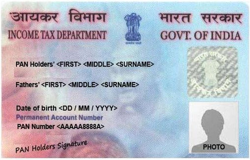

In [7]:
original

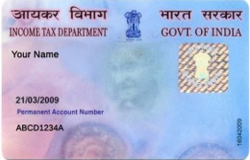

In [8]:
tampered

In [9]:
#to load the 2 images
original=cv2.imread('pan_card_tampering/image/original.png')
tampered=cv2.imread('pan_card_tampering/image/tampered.png')

In [10]:
# convert image to gray scale for better understanding by the opencv library
original_gray=cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)
tampered_gray=cv2.cvtColor(tampered,cv2.COLOR_BGR2GRAY)

In [11]:
#structural similarity between the two images are considered
(score,diff)=structural_similarity(original_gray,tampered_gray,full=True)
diff=(diff*255).astype("uint8")
print("SSIM :{}".format(score))

SSIM :0.31686135690489126


In [12]:
thresh=cv2.threshold(diff,0,255,cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts=cv2.findContours(thresh.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cnts=imutils.grab_contours(cnts)

In [13]:
for c in cnts:
    # applying contours on image
    (x, y, w, h) = cv2.boundingRect(c)
    cv2.rectangle(original, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.rectangle(tampered, (x, y), (x + w, y + h), (0, 0, 255), 2)

the original image


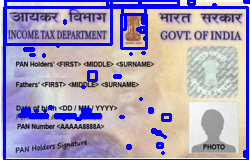

In [14]:
#original image with contour
print("the original image")
Image.fromarray(original)

the tampered image


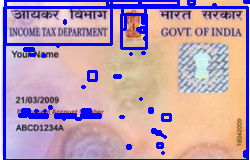

In [15]:
#tampered image with contour
print("the tampered image")
Image.fromarray(tampered)

the difference image in black is shown


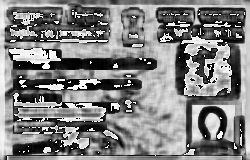

In [16]:
#difference image with black
print("the difference image in black is shown")
Image.fromarray(diff)

the difference image in white is shown


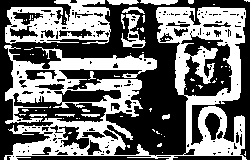

In [22]:
#difference image in white
print("the difference image in white is shown")
Image.fromarray(thresh)